# Part 3: Analyzing ERPs in a Go/NoGo Task 🧠

Welcome to the final part of our workshop! By now, our EEG data is fully preprocessed, cleaned from artifacts,we cut into epochs around our stimuli and analysed behavior.

Now comes the exciting part: We will extract the **Event-Related Potentials (ERPs)**. ERPs represent the brain's averaged electrical response to a specific event. In our Go/NoGo task, we are particularly interested in the differences between trials where participants had to act (Go) and trials where they had to inhibit their response (NoGo).

### Setup and Loading Data
First, let's import the necessary libraries and load our preprocessed epochs and the electrode coordinates.

In [1]:
# Interactive Plots
%matplotlib widget

import mne
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

mne.set_log_level('WARNING')  # suppress info messages, keep warnings

import os.path as op

# Load the preprocessed epochs
sub_id   = 'sub-4'
DATA_DIR = f'../data/hackathon_data/derivatives/{sub_id}/eeg'


epo_path = op.join(DATA_DIR, f'{sub_id}_day2_task-gonogo_epo.fif')
epochs = mne.read_epochs(epo_path, preload=True)

# Use standard electrode positions (same as Day 2)
montage = mne.channels.make_standard_montage('standard_1020')
epochs.set_montage(montage, on_missing='ignore')

print(epochs.info)

<Info | 12 non-empty values
 bads: 6 items (P10, AF7, Fp2, Fp1, AF4, AF8)
 ch_names: Fp1, Fz, F3, F7, F9, FC5, FC1, C3, T7, CP5, CP1, Pz, P3, P7, P9, ...
 chs: 63 EEG
 custom_ref_applied: True
 dig: 66 items (3 Cardinal, 63 EEG)
 file_id: 4 items (dict)
 highpass: 0.2 Hz
 lowpass: 40.0 Hz
 meas_date: 2026-03-28 10:54:45 UTC
 meas_id: 4 items (dict)
 nchan: 63
 projs: []
 sfreq: 256.0 Hz
>


## Task 1: Calculating and Plotting Evoked Responses

To reveal the underlying ERP, we need to average our single trials (epochs). Random background noise (like spontaneous brain activity) will average out to zero, leaving only the signal that is time-locked to our stimuli.

**Your Task:**
1. Create an averaged response (`Evoked` object) for the **Go** trials.
2. Create an averaged response for the **NoGo** trials.
3. Plot the ERP for the NoGo condition.

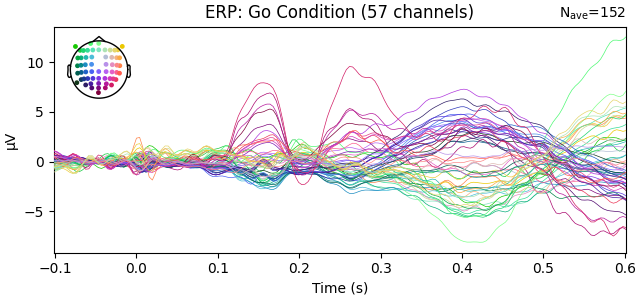

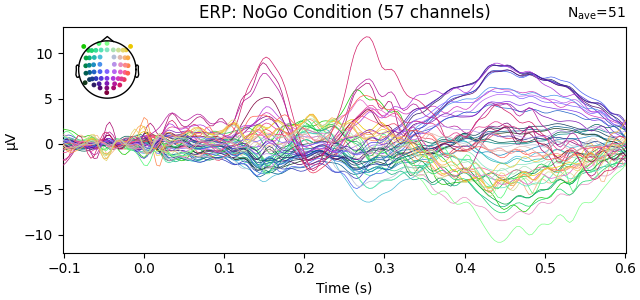

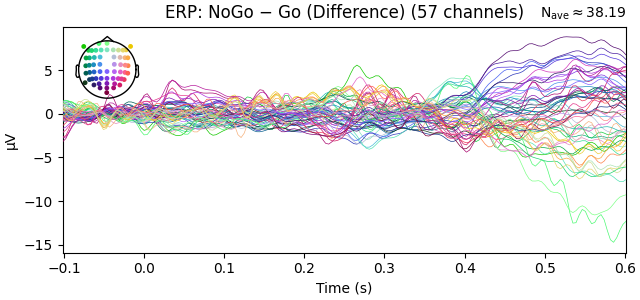

In [2]:
# Create Evoked objects by averaging epochs per condition
### NOTE: Remove the `.average()` part for the exercise
evoked_go   = epochs['Go'].average()
evoked_nogo = epochs['NoGo'].average()

# Compute the difference wave (NoGo minus Go)
# This isolates the inhibition-related activity (N2, P3 NoGo effect)
evoked_diff = mne.combine_evoked([evoked_nogo, evoked_go], weights=[1, -1])
evoked_diff.comment = 'NoGo − Go'

# Plot all three: Go, NoGo, and the difference wave
### NOTE: Remove the plot commands for the exercise
fig_go   = evoked_go.plot(spatial_colors=True, titles='ERP: Go Condition')
fig_nogo = evoked_nogo.plot(spatial_colors=True, titles='ERP: NoGo Condition')
fig_diff = evoked_diff.plot(spatial_colors=True, titles='ERP: NoGo − Go (Difference)')

## Task 2: Comparing Conditions

Looking at conditions separately is nice, but comparing them in a single plot is much more insightful! We want to see if the brain's response differs when inhibiting an action compared to executing it.

**Your Task:**
Plot the **Go** and **NoGo** conditions together. Focus on a specific region of interest (e.g., the fronto-central electrode 'FCz', which is typical for inhibitory control tasks).

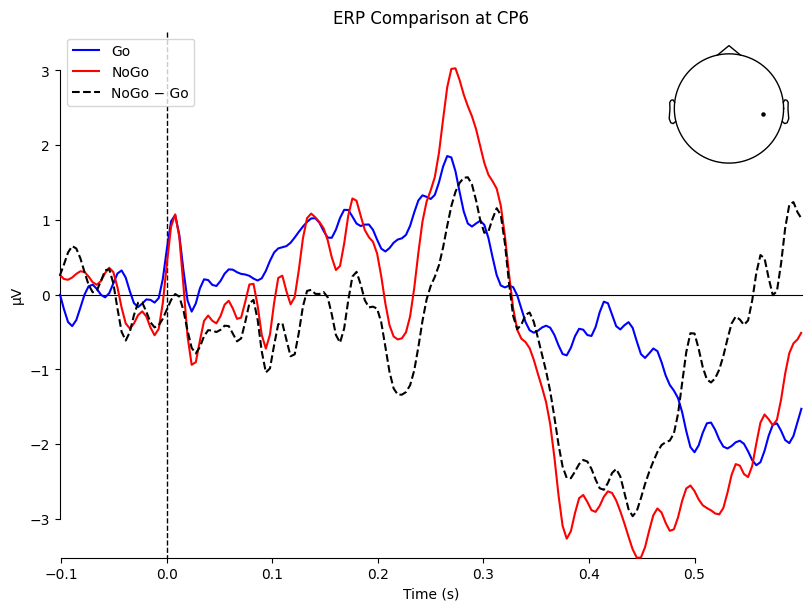

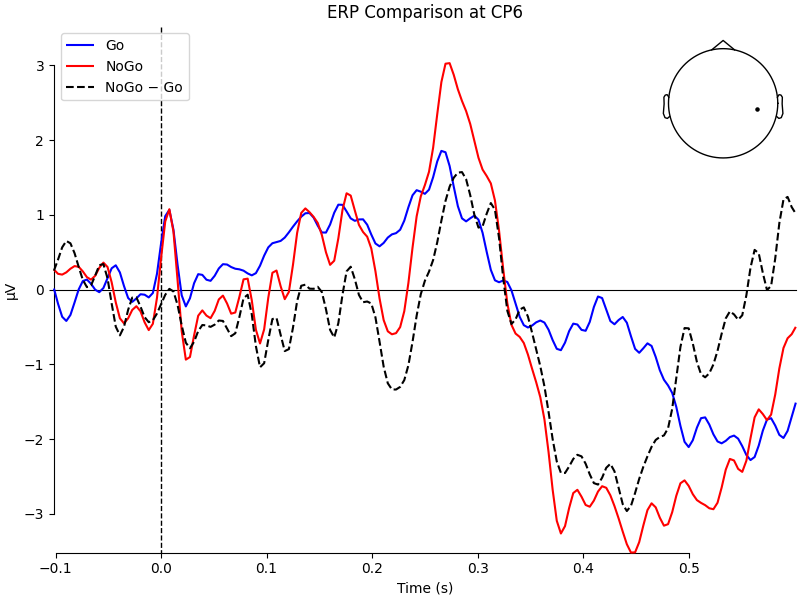

KeyboardInterrupt: 

In [ ]:
# Defining a dictionary containing all three waveforms
### NOTE: Remove dictionary for the exercise
evokeds_dict = {'Go': evoked_go, 'NoGo': evoked_nogo, 'NoGo − Go': evoked_diff}


import time
from IPython.display import clear_output

for electrode in epochs.info["ch_names"]: 
    clear_output(wait=True)  # Clear previous output
    fig_compare = mne.viz.plot_compare_evokeds(
        evokeds_dict,
        picks=electrode,
        colors={'Go': 'blue', 'NoGo': 'red', 'NoGo − Go': 'black'},
        linestyles={'Go': '-', 'NoGo': '-', 'NoGo − Go': '--'},
        title=f'ERP Comparison at {electrode}',  # Dynamic title
        show_sensors=True,
        show = False
    )
    display(fig_compare[0]);  # Explicitly display
    plt.pause(2)
    plt.close(fig_compare[0])

'''
#static version

fig_compare = mne.viz.plot_compare_evokeds(
        evokeds_dict,
        picks='Fz',
        colors={'Go': 'blue', 'NoGo': 'red', 'NoGo − Go': 'black'},
        linestyles={'Go': '-', 'NoGo': '-', 'NoGo − Go': '--'},
        title=f'ERP Comparison at Fz',  # Dynamic title
        show_sensors=True
    )
    
'''


## Overall (n = 4)

  sub-1: Go = 268 epochs, NoGo = 97 epochs
  sub-2: Go = 189 epochs, NoGo = 63 epochs
  sub-3: Go = 148 epochs, NoGo = 41 epochs
  sub-4: Go = 152 epochs, NoGo = 51 epochs


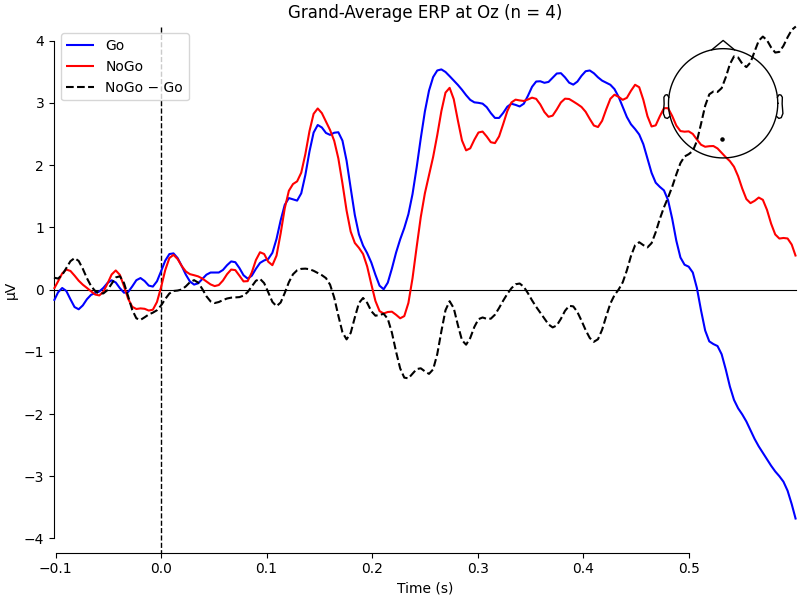


Included in grand average: 4 participants


In [ ]:
# Grand-Average ERPs across all participants 
participantsA = ['sub-1', 'sub-2', 'sub-3', 'sub-4']

evoked_go_list   = []
evoked_nogo_list = []
evoked_diff_list = []

for sub_id in participantsA:
    DATA_DIR = f'../data/hackathon_data/derivatives/{sub_id}/eeg'
    epo_path = op.join(DATA_DIR, f'{sub_id}_day2_task-gonogo_epo.fif')
    epo = mne.read_epochs(epo_path, preload=True)

    if len(epo) == 0:
        print(f'  {sub_id}: SKIPPED (0 epochs)')
        continue

    ev_go   = epo['Go'].average()
    ev_nogo = epo['NoGo'].average()
    ev_diff = mne.combine_evoked([ev_nogo, ev_go], weights=[1, -1])

    evoked_go_list.append(ev_go)
    evoked_nogo_list.append(ev_nogo)
    evoked_diff_list.append(ev_diff)
    print(f'  {sub_id}: Go = {len(epo["Go"])} epochs, NoGo = {len(epo["NoGo"])} epochs')

# Compute grand averages
grand_go   = mne.grand_average(evoked_go_list)
grand_nogo = mne.grand_average(evoked_nogo_list)
grand_diff = mne.grand_average(evoked_diff_list)

grand_go.comment   = 'Go'
grand_nogo.comment = 'NoGo'
grand_diff.comment = 'NoGo − Go'

# Plot comparison at Fz
fig = mne.viz.plot_compare_evokeds(
    {'Go': grand_go, 'NoGo': grand_nogo, 'NoGo − Go': grand_diff},
    picks='Fz',
    colors={'Go': 'blue', 'NoGo': 'red', 'NoGo − Go': 'black'},
    linestyles={'Go': '-', 'NoGo': '-', 'NoGo − Go': '--'},
    title=f'Grand-Average ERP at Fz (n = {len(evoked_go_list)})',
    show_sensors=True
)
print(f'\nIncluded in grand average: {len(evoked_go_list)} participants')

## Task 3: Statistical Testing 📊

Visualizing differences in ERPs is crucial, but we also need to prove that these differences are statistically significant. Is the brain's response in the NoGo condition truly different from the Go condition, or is it just random noise?

To keep things simple and intuitive, we will focus on a **Region of Interest (ROI)**. We will extract the mean voltage for a specific electrode in a specific time window for every single trial, and then compare the two groups of trials using an independent t-test.

**Your Task:**
1. Define an ROI: Select a frontal electrode (e.g `'Fz'` )and a time window capturing the P3 component (e.g., `0.250` to `0.350` seconds).
2. Extract the data for this ROI from both the Go and NoGo epochs and average the voltage across the time window.
3. Perform an independent t-test (`scipy.stats.ttest_ind`) to compare the trial-by-trial mean amplitudes.

In [ ]:
# Define the Region of Interest (ROI)
channel_of_interest = 'Fz'
t_start = 0.150
t_end   = 0.250

# Extract data for the ROI
### NOTE: Remove the extraction and averaging lines for the exercise
go_data   = epochs['Go'].copy().pick(channel_of_interest).crop(tmin=t_start, tmax=t_end).get_data()
nogo_data = epochs['NoGo'].copy().pick(channel_of_interest).crop(tmin=t_start, tmax=t_end).get_data()

# Average across the time window (axis=-1) to get one voltage value per trial
go_means   = np.mean(go_data, axis=-1).squeeze()
nogo_means = np.mean(nogo_data, axis=-1).squeeze()

# Single-subject exploratory t-test (trial-level, Welch's)
### NOTE: Remove the t-test logic for the exercise
t_stat, p_val = stats.ttest_ind(go_means, nogo_means, equal_var=False)

print(f"Single-subject analysis for {channel_of_interest} ({t_start*1000:.0f}–{t_end*1000:.0f} ms)")
print(f"  Mean amplitude Go:   {np.mean(go_means)*1e6:.2f} µV")
print(f"  Mean amplitude NoGo: {np.mean(nogo_means)*1e6:.2f} µV")
print(f"  T-statistic: {t_stat:.3f}")
print(f"  P-value:     {p_val:.4f}")

if p_val < 0.05:
    print("  → Statistically significant!")
else:
    print("  → No significant difference.")

print("\nNote: This is a trial-level test for ONE participant (exploratory).")
print("For a proper group analysis, average per participant first, then run a paired t-test across participants (see bonus cell below).")

Single-subject analysis for Oz (150–250 ms)
  Mean amplitude Go:   1.69 µV
  Mean amplitude NoGo: -0.28 µV
  T-statistic: 1.878
  P-value:     0.0630
  → No significant difference.

Note: This is a trial-level test for ONE participant (exploratory).
For a proper group analysis, average per participant first, then run a paired t-test across participants (see bonus cell below).


## Task 4: Spatial Distribution (Topographies)

A simple line plot shows us *when* something happens, but a **Topographical Map** shows us *where* on the scalp the activity is distributed. 

**Your Task:**
Create a topomap for the **NoGo** condition. Choose specific time points to plot, for instance, the typical time windows for the N2 and P3 components (e.g., 250 ms and 400 ms after the stimulus).

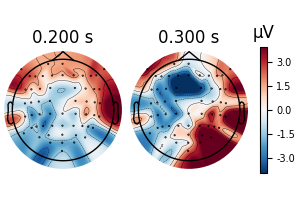

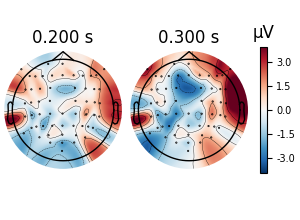

Text(0.5, 0.98, 'NoGo − Go Topographies (N2 & P3)')

In [12]:
# Define the time points of interest (in seconds)
times_of_interest = [0.200, 0.300]

# Plot topographies — use extrapolate='local' to avoid distortion
# beyond the electrode coverage (equivalent to convex hull in MATLAB)
### NOTE: Remove the plot_topomap command for the exercise
fig_topo_nogo = evoked_nogo.plot_topomap(
    times=times_of_interest,
    ch_type='eeg',
    time_unit='s',
    vlim=(-4, 4)
)
fig_topo_nogo.suptitle('NoGo Topographies (N2 & P3)')

fig_topo_diff = evoked_diff.plot_topomap(
    times=times_of_interest,
    ch_type='eeg',
    time_unit='s',
    vlim=(-4, 4)
)
fig_topo_diff.suptitle('NoGo − Go Topographies (N2 & P3)')

## Overall (n = 4)

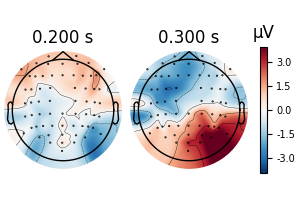

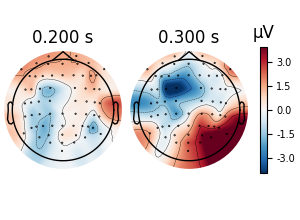

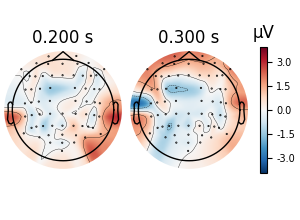

Text(0.5, 0.98, 'Grand-Average NoGo − Go (n = 4)')

In [13]:
# Grand-Average Topographies
# (uses grand_go, grand_nogo, grand_diff from the cell above)

times_of_interest = [0.200, 0.300]

fig_topo_go = grand_go.plot_topomap(
    times=times_of_interest,
    ch_type='eeg',
    time_unit='s',
    vlim=(-4, 4)
)
fig_topo_go.suptitle(f'Grand-Average Go (n = {len(evoked_go_list)})')

fig_topo_nogo = grand_nogo.plot_topomap(
    times=times_of_interest,
    ch_type='eeg',
    time_unit='s',
    vlim=(-4, 4)
)
fig_topo_nogo.suptitle(f'Grand-Average NoGo (n = {len(evoked_nogo_list)})')

fig_topo_diff = grand_diff.plot_topomap(
    times=times_of_interest,
    ch_type='eeg',
    time_unit='s',
    vlim=(-4, 4)
)
fig_topo_diff.suptitle(f'Grand-Average NoGo − Go (n = {len(evoked_diff_list)})')

---
## Part 4 · Group-Level Analysis (Bonus)

### Why a group analysis?

The single-subject t-test above compares **trials within one participant** — it tells us
whether *this particular person* showed a Go/NoGo difference at the chosen electrode and
time window. But to generalise beyond that person, we need a **group-level test**.

### How it works

1. For each participant, compute the **mean amplitude** per condition in the ROI
   (one value per participant per condition — not per trial).
2. Run a **paired t-test** across participants.

This treats each participant as one observation, which is the correct unit of analysis
for generalising to the population.

### Interpreting the results

With only **4 participants**, the test has very limited statistical power
(df = 3). A non-significant result does **not** mean there is no effect —
it means we cannot detect it with this sample size.

**What to look for instead:**
- Does the **direction** of the effect match the literature? (NoGo should be more positive than Go in the N2/P3 window)
- Is the effect **consistent** across participants? (all showing the same direction)
- What **sample size** would be needed for adequate power? (typically 20–30 for ERP studies)

> 💡 A common rule of thumb in ERP research: aim for **at least 20–30 participants**
> per group for reliable statistical inference. *(Luck, 2014)*

> 💡 Consider testing **multiple time windows**: 200–300 ms for the N2 component
> and 350–500 ms for the P3 component — the Go/NoGo effect may be stronger in one
> than the other.

In [10]:
participants = ['sub-1', 'sub-2', 'sub-3', 'sub-4']


channel_of_interest = 'Fz'
t_start = 0.250
t_end   = 0.350

go_group   = []
nogo_group = []



for sub_id in participants:
    DATA_DIR = f'../data/hackathon_data/derivatives/{sub_id}/eeg'
    epo_path = op.join(DATA_DIR, f'{sub_id}_day2_task-gonogo_epo.fif')
    epo = mne.read_epochs(epo_path, preload=True)

    # Skip participants with empty epoch files
    if len(epo) == 0:
        print(f'  {sub_id}: SKIPPED (0 epochs — re-run Day 2 preprocessing)')
        continue

    # Mean amplitude per condition for this participant (one value each)
    go_mean   = epo['Go'].copy().pick(channel_of_interest).crop(tmin=t_start, tmax=t_end).get_data().mean() * 1e6
    nogo_mean = epo['NoGo'].copy().pick(channel_of_interest).crop(tmin=t_start, tmax=t_end).get_data().mean() * 1e6

    go_group.append(go_mean)
    nogo_group.append(nogo_mean)
    print(f'  {sub_id}: Go = {go_mean:.2f} µV, NoGo = {nogo_mean:.2f} µV')

go_group   = np.array(go_group)
nogo_group = np.array(nogo_group)

# Paired t-test across participants (proper group-level inference)
t_stat, p_val = stats.ttest_rel(go_group, nogo_group)

print(f"\nGroup analysis at {channel_of_interest} ({t_start*1000:.0f}–{t_end*1000:.0f} ms)")
print(f"  Mean Go:   {go_group.mean():.2f} µV (SD {go_group.std():.2f})")
print(f"  Mean NoGo: {nogo_group.mean():.2f} µV (SD {nogo_group.std():.2f})")
print(f"  Paired t({len(participants)-1}) = {t_stat:.3f}, p = {p_val:.4f}")

  sub-1: Go = -0.70 µV, NoGo = -0.05 µV
  sub-2: Go = -0.42 µV, NoGo = 1.37 µV
  sub-3: Go = -6.04 µV, NoGo = -6.26 µV
  sub-4: Go = -2.61 µV, NoGo = -3.55 µV

Group analysis at Fz (250–350 ms)
  Mean Go:   -2.44 µV (SD 2.24)
  Mean NoGo: -2.12 µV (SD 2.99)
  Paired t(3) = -0.544, p = 0.6243
